In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask


from firedrake import *
from firedrake.__future__ import interpolate

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

# Just run on the coarse mesh for now

In [2]:
### Create the mesh ###

coarse_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
coarse_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"
coarse_resamp_factor=1/200
layers = 10

mesh = mesh_creator(coarse_bed_path, coarse_surf_path, resamp_factor=coarse_resamp_factor, layers=layers)
x_src, y_src, z_src = SpatialCoordinate(mesh)

In [3]:
### Run the flow model ###

flow, Y = scripts.model_modules.run_flow_model(mesh)

# Plot a cross sections

In [6]:
flowline_surf = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC1902_surface_rema_100m.csv')
flowline_bed = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC1902_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

z_coords = np.linspace(1300, 2200, 500)

In [7]:
vel_prof=[]
u_prof = []
v_prof = []
z_prof = []
vel_prof_coords = []
for n in range(len(flowline_xs)):


    for z_coord in z_coords:
        try:
            velocity = flow.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
            vel_prof.append(velocity)
            u_prof.append(velocity[0])
            v_prof.append(velocity[1])
            z_prof.append(velocity[2])
            distance = np.sqrt((flowline_xs[n]-flowline_xs[0])**2 + (flowline_ys[n]-flowline_ys[0])**2)
            vel_prof_coords.append([distance, z_coord])

        except:
            continue

vel_prof=np.array(vel_prof)
u_prof = np.array(u_prof)
v_prof = np.array(v_prof)
z_prof = np.array(z_prof)
vel_prof_coords = np.array(vel_prof_coords)

Text(0.5, 1.0, 'Velocity (v-component)')

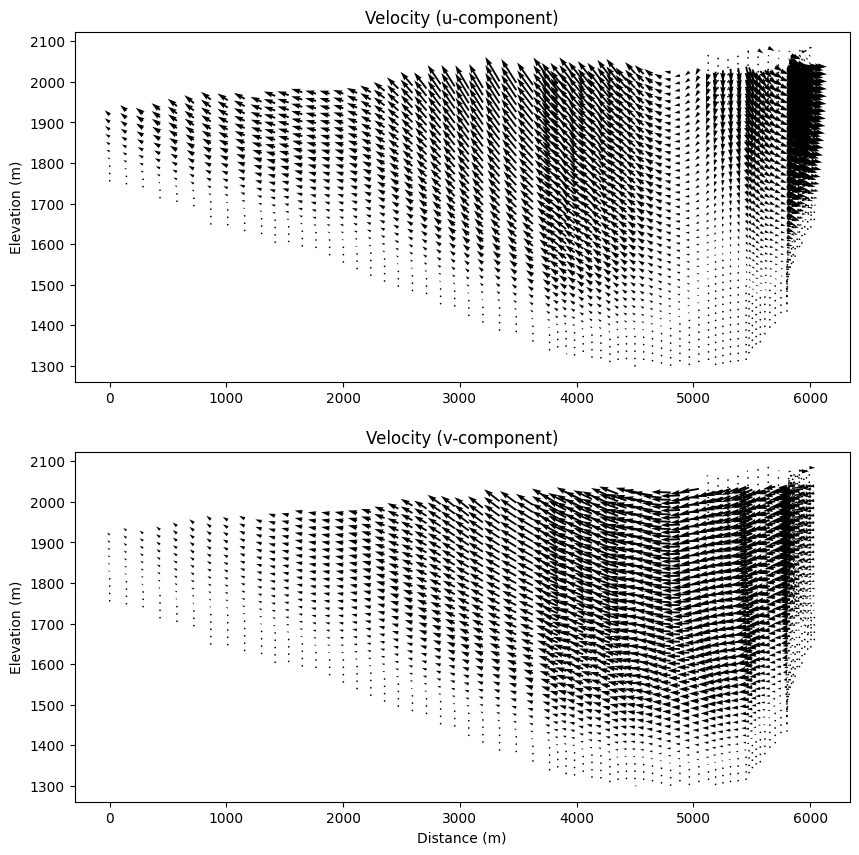

In [9]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=[10,10])

ax1.quiver(vel_prof_coords[:,0][::10], vel_prof_coords[:,1][::10], u_prof[::10], z_prof[::10],angles='xy', scale_units='xy', scale=None,)
ax2.quiver(vel_prof_coords[:,0][::10], vel_prof_coords[:,1][::10], v_prof[::10], z_prof[::10],angles='xy', scale_units='xy', scale=None,)
ax1.set_ylabel('Elevation (m)')
ax2.set_ylabel('Elevation (m)')

ax2.set_xlabel('Distance (m)')

ax1.set_title('Velocity (u-component)')
ax2.set_title('Velocity (v-component)')

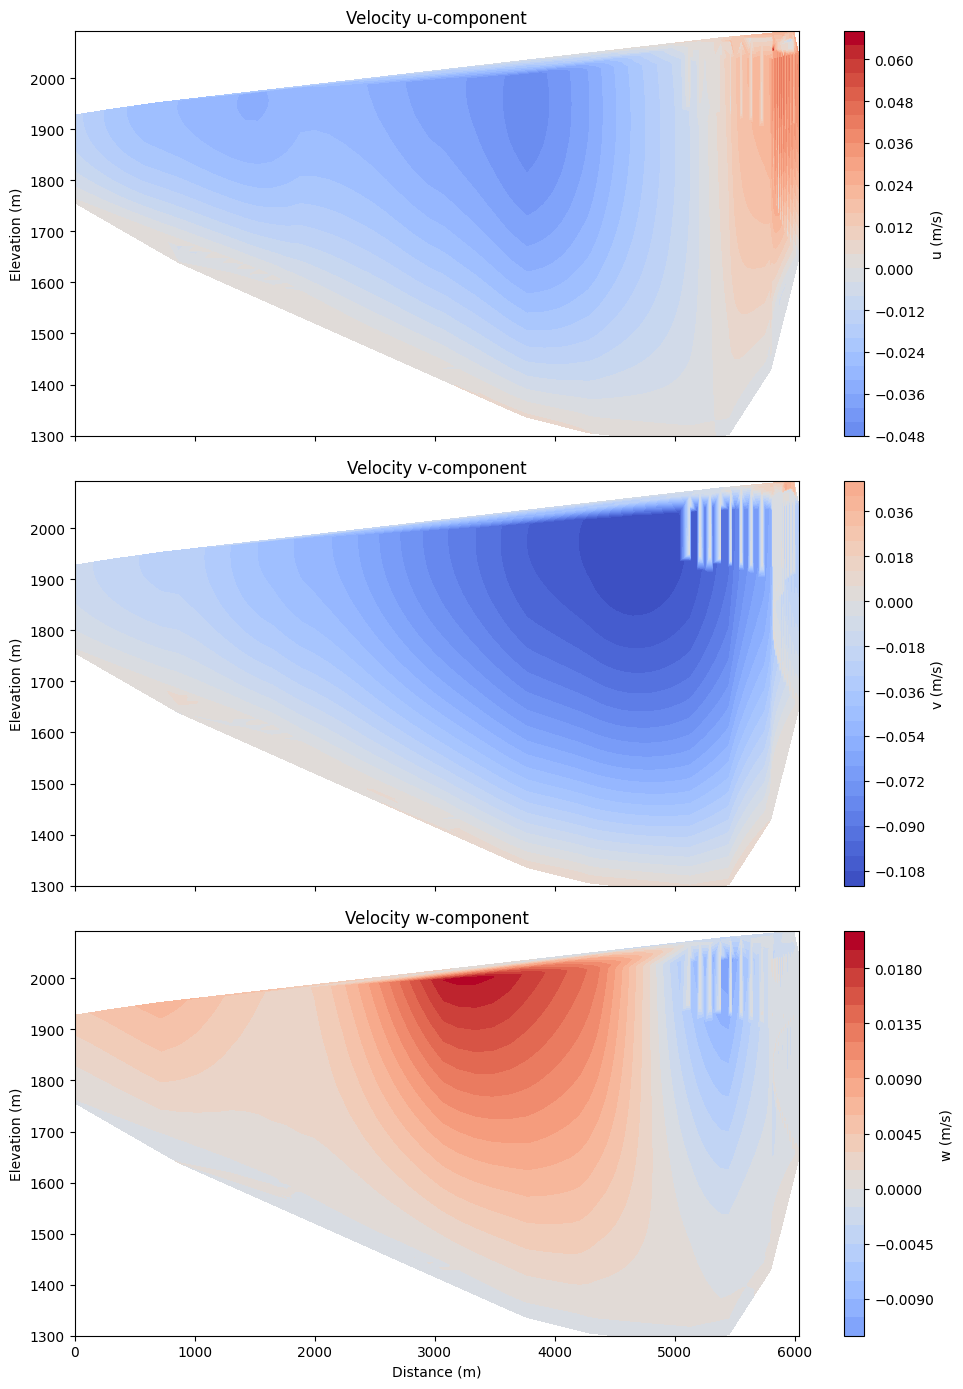

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(10, 14), sharex=True
)

x = vel_prof_coords[:, 0]   # distance
z = vel_prof_coords[:, 1]   # elevation

levels = 30  # increase for smoother contours

vm = np.max(np.abs(u_prof))
cu = ax1.tricontourf(x, z, u_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.max(np.abs(v_prof))
cv = ax2.tricontourf(x, z, v_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.max(np.abs(z_prof))
cw = ax3.tricontourf(x, z, z_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')

# Labels
ax1.set_title('Velocity u-component')
ax2.set_title('Velocity v-component')
ax3.set_title('Velocity w-component')

ax3.set_xlabel('Distance (m)')
ax1.set_ylabel('Elevation (m)')
ax2.set_ylabel('Elevation (m)')
ax3.set_ylabel('Elevation (m)')

# Optional: invert elevation if depth-like
# ax1.invert_yaxis()
# ax2.invert_yaxis()
# ax3.invert_yaxis()

# Colorbars
fig.colorbar(cu, ax=ax1, label='u (m/s)')
fig.colorbar(cv, ax=ax2, label='v (m/s)')
fig.colorbar(cw, ax=ax3, label='w (m/s)')

plt.tight_layout()
